# W1Q2 — Active Customer Snapshot
**Question:** How many active customers do we have in Dec 2022 across each funnel stage?  
Did we see an increase vs. Nov 2022 (MoM) and Dec 2021 (YoY)?  
How many customers returned to the platform (upsell or renewal)?

**Audience:** Product & Marketing Teams · Leadership  
**Data source:** `ANALYTICS.MARTS.MART_SUBSCRIPTION_FUNNEL`  
**SQL:** `sql/W1Q2_active_customers_snapshot.sql`

---

## Active User Definitions
| Stage | Definition |
|-------|------------|
| **Signup** | User registered on the platform in the calendar month |
| **Free trial** | 7-day trial started in the calendar month |
| **3-month subscriber** | Subscription started within the past 90 days from month end |
| **12-month subscriber** | Subscription started within the past 365 days from month end |
| **Upsold to 12m** | Had a 3m subscription and converted to 12m in that month |
| **Renewed 3m** | Had a prior trial, got a 3m subscription in the month (no 12m) |

## Setup

In [7]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.connection import query

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

## Load Data

In [8]:
with open('../sql/W1Q2_active_customers_snapshot.sql') as f:
    sql = f.read()

df = query(sql)
df

Task was destroyed but it is pending!
task: <Task pending name='Task-103' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/jean-sebastienprovost/Desktop/Jobs/dailydatascientist/github/geekybald_analysis/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-104' coro=<Kernel.shell_main() running at /Users/jean-sebastienprovost/Desktop/Jobs/dailydatascientist/github/geekybald_analysis/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/jean-sebastienprovost/Desktop/Jobs/dailydatascientist/github/geekybald_analysis/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/jean-sebastienprovost/Desktop/Jobs/dailydatascientist/github/geekybald_analysis/.venv/lib/python3.13/site-packages/urllib3/connection.py:459: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  header_keys = frozenset(to_str(k.lower(

,label,month_start,new_signups,active_trials,active_3m_subscribers,active_12m_subscribers,upsold_to_12m_this_month,renewed_3m_this_month
0,Dec 2021 (YoY),2021-12-01,572,268,491,1253,194,26
1,Nov 2022 (prior month),2022-11-01,3561,1414,2851,3457,608,511
2,Dec 2022 (current),2022-12-01,53,26,2303,4030,763,434


## ⚠️ Data Quality Warning — DN-001

**December 2022 signup and trial figures are unreliable.**

`signup_date` and `trial_date` are truncated after **December 1, 2022** — the entire month's
figures reflect a single day of data, not a full month.

| Metric | December 2022 status |
|--------|---------------------|
| `new_signups` | ❌ One day only — do not use for MoM/YoY |
| `active_trials` | ❌ One day only — do not use for MoM/YoY |
| `active_3m_subscribers` | ✅ Valid — data runs through Dec 30 |
| `active_12m_subscribers` | ✅ Valid — data runs through Dec 31 |
| `upsold_to_12m_this_month` | ✅ Valid |
| `renewed_3m_this_month` | ✅ Valid |

The MoM comparison table below separates these two groups accordingly.

## MoM and YoY Comparison Table

In [9]:
metrics = [
    'new_signups', 'active_trials',
    'active_3m_subscribers', 'active_12m_subscribers',
    'upsold_to_12m_this_month', 'renewed_3m_this_month'
]

dec21 = df[df['label'].str.contains('YoY')][metrics].values[0]
nov22 = df[df['label'].str.contains('prior')][metrics].values[0]
dec22 = df[df['label'].str.contains('current')][metrics].values[0]

def pct_change(new, old):
    return round((new - old) / old * 100, 1) if old != 0 else None

summary = pd.DataFrame({
    'Metric': metrics,
    'Dec 2021': dec21,
    'Nov 2022': nov22,
    'Dec 2022': dec22,
    'MoM % - Dec 2022': [pct_change(d, n) for d, n in zip(dec22, nov22)],
    'YoY % - Dec 2022': [pct_change(d, n) for d, n in zip(dec22, dec21)],
    'YoY % - Nov 2022': [pct_change(d, n) for d, n in zip(nov22, dec21)],
})
summary['Metric'] = summary['Metric'].str.replace('_', ' ').str.title()
summary

,Metric,Dec 2021,Nov 2022,Dec 2022,MoM % - Dec 2022,YoY % - Dec 2022,YoY % - Nov 2022
0,New Signups,572,3561,53,-98.5,-90.7,522.6
1,Active Trials,268,1414,26,-98.2,-90.3,427.6
2,Active 3M Subscribers,491,2851,2303,-19.2,369.0,480.7
3,Active 12M Subscribers,1253,3457,4030,16.6,221.6,175.9
4,Upsold To 12M This Month,194,608,763,25.5,293.3,213.4
5,Renewed 3M This Month,26,511,434,-15.1,1569.2,1865.4


## Chart — Active Customers by Funnel Stage

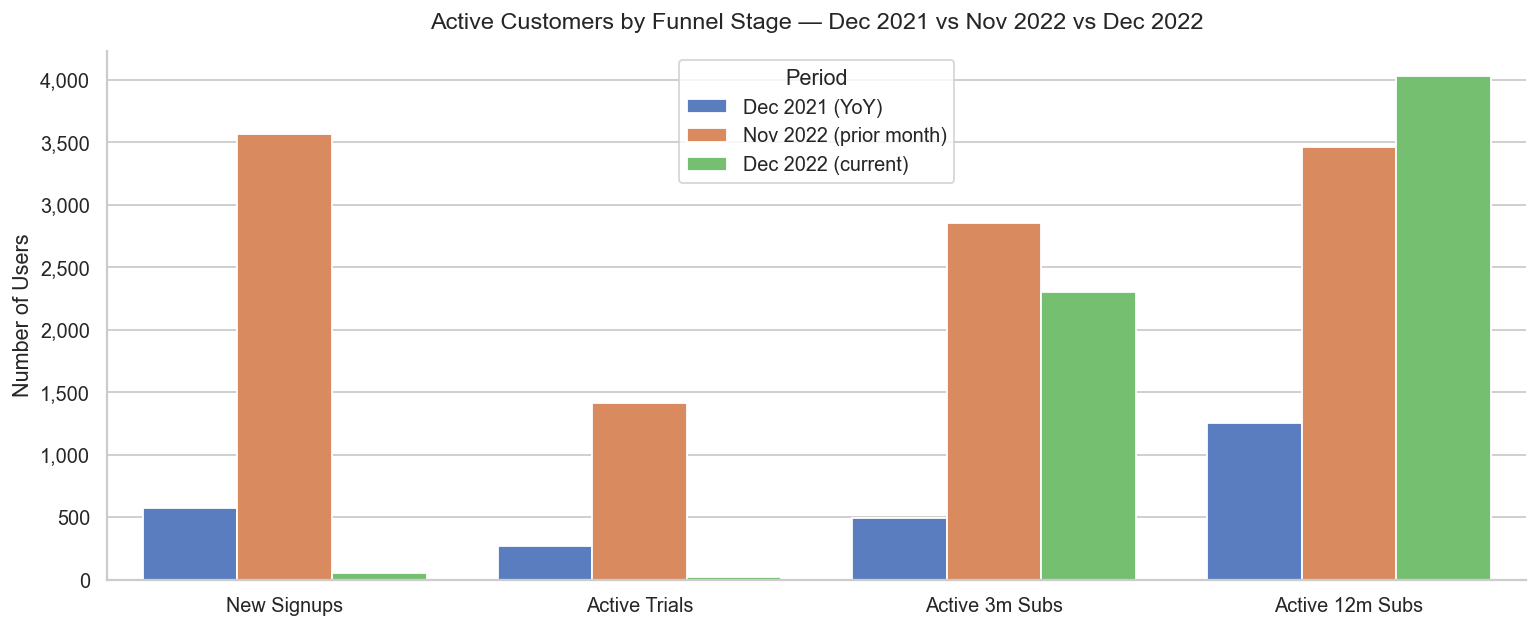

In [10]:
plot_metrics = {
    'new_signups':            'New Signups',
    'active_trials':          'Active Trials',
    'active_3m_subscribers':  'Active 3m Subs',
    'active_12m_subscribers': 'Active 12m Subs',
}

plot_df = df[['label'] + list(plot_metrics.keys())].copy()
plot_df = plot_df.rename(columns=plot_metrics)
plot_df = plot_df.melt(id_vars='label', var_name='Stage', value_name='Count')

fig, ax = plt.subplots()
sns.barplot(data=plot_df, x='Stage', y='Count', hue='label', palette='muted', ax=ax)
ax.set_title('Active Customers by Funnel Stage — Dec 2021 vs Nov 2022 vs Dec 2022', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Number of Users')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Period')
sns.despine()
plt.tight_layout()
plt.savefig('../output/W1Q2_active_customers_snapshot.png')
plt.show()

## Findings

- **Signups MoM / YoY:** These results are not accurate for Dec 2022 since data capture is incomplete. 
- **Trials MoM / YoY:** These results are not accurate for Dec 2022 since data capture is incomplete. Ask the business whether trials are still available and whether an issue occurred with the signup process. 
- **3m subscribers MoM / YoY:** 1) -19.5% MoM Worth asking engineering if data capture ran properly since an issue was observed with signups and trials
        2) +369%, which is coherent with observed growth. However, worth exploring if data capture underestimates the number
- **12m subscribers MoM / YoY:** +16% MoM and +221% YoY, which is consistent with previous growth. 
- **Returning customers (upsell + renewal):** Reported separately — they represent different behaviors. **Upsells (3m → 12m):** 763 in Dec 2022, up +25.5% MoM and +293% YoY — strong revenue expansion signal, users are committing to the platform long-term. **Renewals (3m → 3m):** 434 in Dec 2022, down -15.1% MoM. The drop is worth watching: it could indicate churn risk among short-term subscribers, or — more optimistically — that renewal-eligible users are choosing to upsell instead (consistent with the upsell surge). The combined returning base is 1,197 in Dec 2022, up +7% MoM and +444% YoY. Both metrics are unaffected by DN-001.
- **Recommendation:** Prioritize three follow-ups: (1) Escalate the signup/trial pipeline failure to engineering — Dec 2022 top-of-funnel is blind and Nov 2022 may be the last reliable acquisition signal. (2) Investigate the renewal dip: segment by cohort to determine whether the -15% MoM is structural churn or upsell cannibalization. (3) The upsell growth (+25.5% MoM) is the strongest signal in this snapshot — understand what drove it (campaign, product change, seasonal?) to inform whether it can be replicated.